In [55]:
import statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

airbnb_df = pd.read_csv('belize_airbnb_listings.csv')
airbnb_df.head()

# the survey data would not load for some reason, it kept
# telling me there was an unreadable character in the data
# even after i redownloaded the data. so, i used the belize 
# airbnb data instead

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,36666,Mo's Cozy Casa w/ veranda & access to dock,157752,Monique,Belize,Belize Islands,17.74786,-88.02398,Entire home/apt,141,3,250,2/23/2021,2.00,5,225
1,36690,Mo's Cozy Cabana w/ comfy veranda & access to ...,157752,Monique,Belize,Belize Islands,17.74832,-88.02474,Entire home/apt,71,3,316,2/19/2021,2.46,5,164
2,108932,Purple House eco solar w/ ocean & wildlife views,563377,Michael,Belize,Belize Islands,17.73221,-88.03824,Entire home/apt,191,2,30,3/14/2020,0.78,1,364
3,110483,Michelo's fuchsia suite,567809,Michel,Stann Creek,Stann Creek Mainland,16.52114,-88.36926,Hotel room,121,1,27,2/24/2020,0.29,3,331
4,120115,Seaside Villas Second Floor Unit #4,604999,Bobbi,Belize,Belize Islands,17.74166,-88.02395,Entire home/apt,343,1,30,3/18/2020,0.64,22,203


In [57]:
from sklearn.preprocessing import LabelEncoder

class_labels = LabelEncoder()

airbnb_df['neighbourhood_group'] = class_labels.fit_transform(airbnb_df['neighbourhood_group'].values)
airbnb_df['neighbourhood'] = class_labels.fit_transform(airbnb_df['neighbourhood'].values)
airbnb_df['room_type'] = class_labels.fit_transform(airbnb_df['room_type'].values)

airbnb_df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,36666,Mo's Cozy Casa w/ veranda & access to dock,157752,Monique,0,0,17.747860,-88.023980,0,141,3,250,2/23/2021,2.00,5,225
1,36690,Mo's Cozy Cabana w/ comfy veranda & access to ...,157752,Monique,0,0,17.748320,-88.024740,0,71,3,316,2/19/2021,2.46,5,164
2,108932,Purple House eco solar w/ ocean & wildlife views,563377,Michael,0,0,17.732210,-88.038240,0,191,2,30,3/14/2020,0.78,1,364
3,110483,Michelo's fuchsia suite,567809,Michel,4,6,16.521140,-88.369260,1,121,1,27,2/24/2020,0.29,3,331
4,120115,Seaside Villas Second Floor Unit #4,604999,Bobbi,0,0,17.741660,-88.023950,0,343,1,30,3/18/2020,0.64,22,203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2791,48283996,Magical Island,17994012,Ronald,0,0,17.945690,-87.944620,0,1054,3,0,NaN,NaN,2,347
2792,48287613,"The Luxury Suite - Corozal, Bz- 3Bdr/2bthr CASA1",375769845,Michael,2,3,18.374630,-88.400190,0,401,3,0,NaN,NaN,2,302
2793,48296096,Lagoon front apartment w/shared pool - two mi...,76414486,Vacasa Belize,0,0,17.934580,-87.955220,0,252,1,0,NaN,NaN,204,364
2794,48296978,Beachfront Poolside Condo,15308338,Alexandra,0,0,17.930010,-87.957120,0,242,3,0,NaN,NaN,4,364


Text(0.5, 1.0, 'Reviews Counts per Neighborhood')

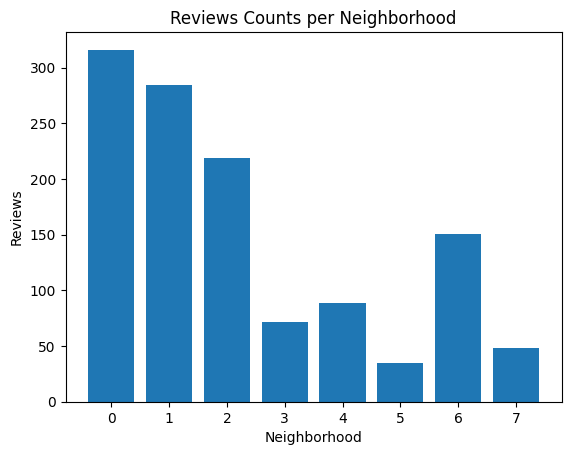

In [58]:
plt.bar(airbnb_df['neighbourhood'], airbnb_df['number_of_reviews'])
plt.xlabel('Neighborhood')
plt.ylabel('Reviews')
plt.title('Reviews Counts per Neighborhood')

# this graph shows the number of reviews from each neighborhood in the dataset. 
# it shows that there are considerably more reviews for neighborhoods 1 and 2 
# than for neighborhoods 5 and 7

C:\Users\kaste\AppData\Local\Temp\ipykernel_49820\4000589439.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x = airbnb_df['minimum_nights'], y = airbnb_df['price'],cmap = "magma")


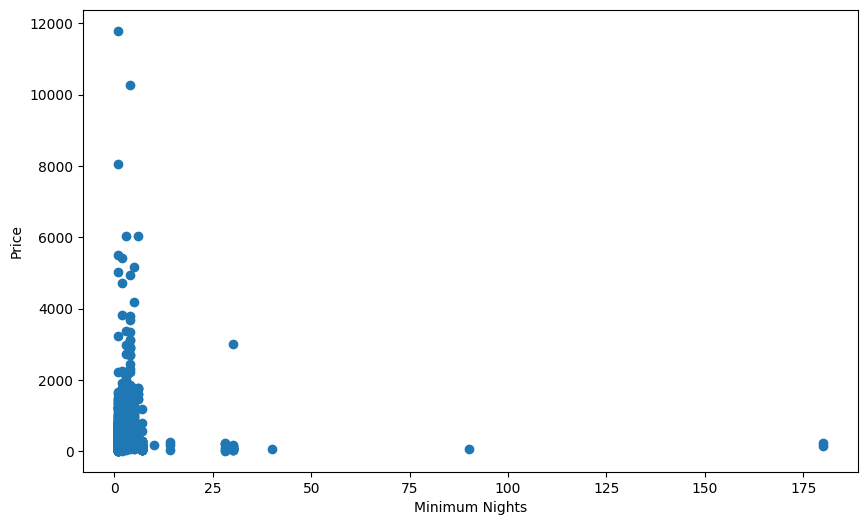

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x = airbnb_df['minimum_nights'], y = airbnb_df['price'],cmap = "magma")
plt.xlabel("Minimum Nights")
plt.ylabel("Price")
plt.show()

# this scatterplot shows the minimum nights required to stay
# at each airbnb vs the prices for those airbnbs. most of the 
# data is clustered at the left side of the graph, meaning that 
# most airbnbs have minimum night requirements of less than 25 nights. 
# based on this graph, there isn't much of a correlation between
# minimum nights and price. 

Text(0, 0.5, 'Room Type')

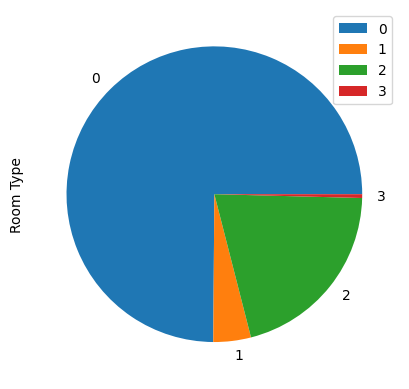

In [ ]:
airbnb_df.groupby('room_type').sum().plot(kind='pie', y='minimum_nights')
plt.ylabel('Room Type')

# this piechart shows the distribution of the different room types.
# there is the largest number of room type 0, for instance, and 
# the smallest number of room type 3. 

C:\Users\kaste\AppData\Local\Temp\ipykernel_49820\2119831449.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x = airbnb_df['calculated_host_listings_count'], y = airbnb_df['number_of_reviews'],cmap = "magma")


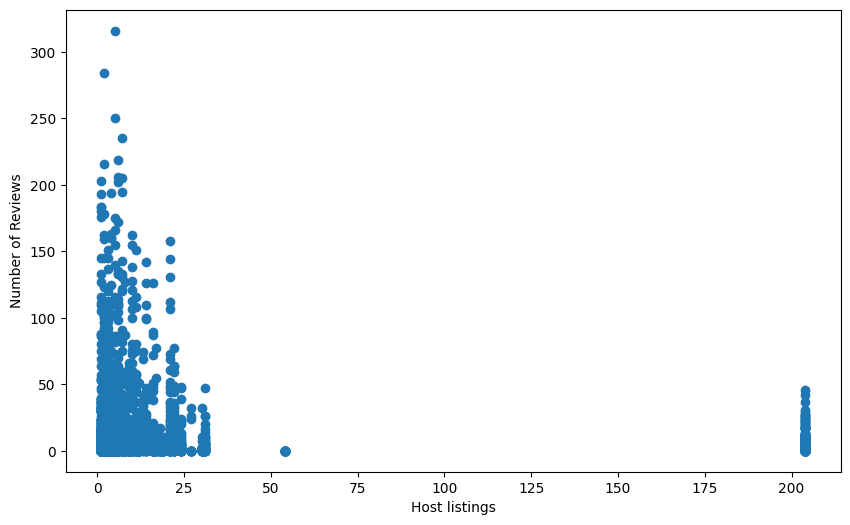

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x = airbnb_df['calculated_host_listings_count'], y = airbnb_df['number_of_reviews'],cmap = "magma")
plt.xlabel("Host listings")
plt.ylabel("Number of Reviews")
plt.show()

# this is a scatterplot showing the number of host listings of each
# entry vs. the number of reviews for that listing. It seems overall that
# there is a correlation of there being less reviews the less host listings
# there are, but the trend is not strong enough to say for sure. 

C:\Users\kaste\AppData\Local\Temp\ipykernel_49820\1820933497.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x = airbnb_df['price'], y = airbnb_df['number_of_reviews'],cmap = "magma")


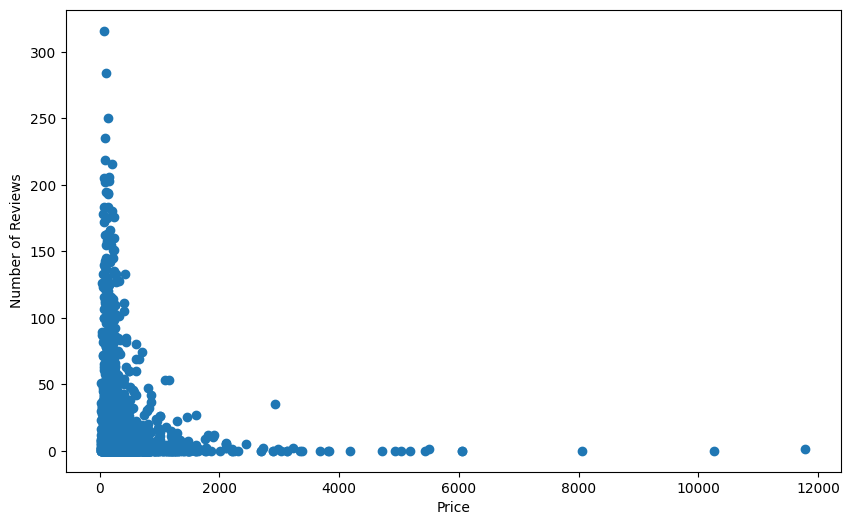

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x = airbnb_df['price'], y = airbnb_df['number_of_reviews'],cmap = "magma")
plt.xlabel("Price")
plt.ylabel("Number of Reviews")
plt.show()
# this scatterplot shows the correlation between the price of
# an airbnb and the number of reviews it has. most of the 
# data, with the exception of some extreme outliers, fall
# towards the origin of the graph, meaning that
# most of the data seems to have a lower price and a lower number of reviews.